Predict Loan Default
Can we predict if a person will default on their loan?


In [ ]:
def func():
    return True

In [ ]:
def fun3c():
    return True

In [ ]:
def func2():
    return False

Read the data from the CSV file. 

In [1]:
import pandas as pd

df = pd.read_csv("data/credit_risk_dataset.csv")
df_raw = df.copy()  # Keep raw data just in case 
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.describe() #see what data we have
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


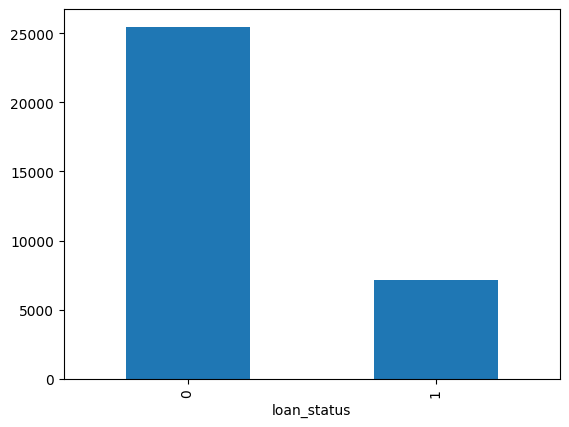

In [3]:
import matplotlib.pyplot as plt
df['loan_status'].value_counts() #target variable to explore 
df['loan_status'].value_counts().plot(kind='bar') #show the bar chart of loan_status 
plt.show()

In [4]:
print("The raw data without any modifications: ")
print(df_raw.isna().sum()) #see what data is missing

# person_emp_length and load_int_rate are the only two columns that have missing values. 
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median()) #fill in missing values using the median of the entire dataset 
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median()) #fill in missing values using the median of the entire dataset

print("\nData after filling missing values: ")
print(df.isna().sum()) #see it correctly filled in the data 

The raw data without any modifications: 
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Data after filling missing values: 
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [5]:
y = df['loan_status'] # target variable
X = pd.get_dummies(df.drop(columns=['loan_status']), drop_first=True) # one one encoding 

print(X.shape)


(32581, 22)


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(26064, 22)
(6517, 22)
(26064,)
(6517,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

#make predictions on the test set
y_pred = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[4830  242]
 [ 658  787]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5072
           1       0.76      0.54      0.64      1445

    accuracy                           0.86      6517
   macro avg       0.82      0.75      0.78      6517
weighted avg       0.85      0.86      0.85      6517

